In [1]:
# Import pandas library for data manipulation and analysis
import pandas as pd

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import RobustScaler for scaling data that may contain outliers
from sklearn.preprocessing import RobustScaler 

# Import numpy for numerical operations
import numpy as np

# Import LabelEncoder for converting categorical labels to numbers
from sklearn.preprocessing import LabelEncoder

# Import imblearn library for handling imbalanced datasets
import imblearn as imb

# Import LightGBM, a gradient boosting framework that uses tree-based learning algorithms
import lightgbm as lgb


# Read the fraud.csv file into a pandas DataFrame
data = pd.read_csv('fraud.csv')

# Display the first 10 rows of the DataFrame to inspect the data
data.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [2]:
# Get the dimensions of the 'data' DataFrame or array
# Returns a tuple with (number of rows, number of columns)
data.shape

(6362620, 11)

In [3]:
# Check for missing values in the dataset
# This returns the count of null values for each column
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [4]:
# Remove the 'isFlaggedFraud' column from the dataset as it's not needed for analysis
# The 'inplace=True' parameter modifies the original dataframe without creating a copy
data.drop(columns=["isFlaggedFraud"], inplace=True)

In [5]:
# Calculate the correlation matrix between transaction amounts and account balances
# This helps identify relationships between:
# - transaction amount
# - sender's balance before and after transaction
# - recipient's balance before and after transaction
data[["amount",'oldbalanceOrg',"newbalanceOrig","oldbalanceDest",'newbalanceDest']].corr()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000


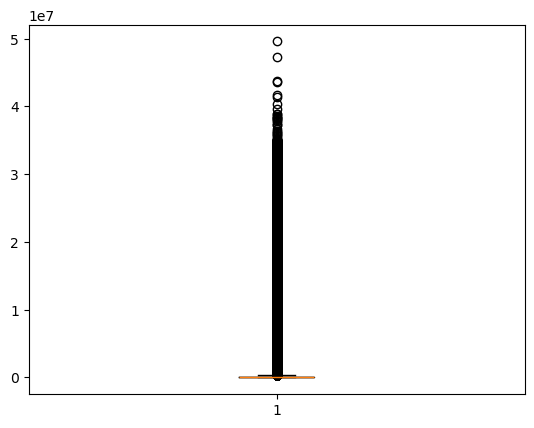

In [6]:
# Create a boxplot to visualize the distribution of 'oldbalanceOrg' column
# Boxplots show median, quartiles, and potential outliers in the data
plt.boxplot(data['newbalanceOrig'])
# Display the plot
plt.show()

In [7]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [8]:
# Initialize the RobustScaler which scales features using statistics that are robust to outliers
scaler=RobustScaler()

# Scale the 'oldbalanceOrg' column and create a new column with the scaled values
# reshape(-1,1) converts the 1D array to a 2D array required by the scaler
data["scaled_oldbalanceOrg"] =  scaler.fit_transform(data["oldbalanceOrg"].values.reshape(-1,1))

# Scale the 'newbalanceOrig' column (sender's new balance)
data["scaled_newbalanceOrig"] = scaler.fit_transform(data["newbalanceOrig"].values.reshape(-1,1))

# Scale the 'oldbalanceDest' column (recipient's old balance)
data["scaled_oldbalanceDest"] = scaler.fit_transform(data["oldbalanceDest"].values.reshape(-1,1))

# Scale the 'newbalanceDest' column (recipient's new balance)
data["scaled_newbalanceDest"] = scaler.fit_transform(data["newbalanceDest"].values.reshape(-1,1))

# Scale the 'amount' column (transaction amount)
data["scaled_amount"] = scaler.fit_transform(data["amount"].values.reshape(-1,1))

In [9]:
# Count the frequency of each unique value in the 'nameOrig' column
# This helps identify how many transactions are associated with each originating account
data["nameOrig"].value_counts()

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
              ..
C98968405      1
C720209255     1
C1567523029    1
C644777639     1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

In [10]:
# Apply logarithmic transformation (log(1+x)) to the scaled balance and amount features
# This helps normalize the distribution of these financial values and reduce the impact of outliers
data["Final_oldbalanceOrg"] =  np.log1p(data["scaled_oldbalanceOrg"])    # Transform sender's initial balance
data["Final_newbalanceOrig"] = np.log1p(data["scaled_newbalanceOrig"])   # Transform sender's final balance
data["Final_oldbalanceDest"] =  np.log1p(data["scaled_oldbalanceDest"])  # Transform recipient's initial balance
data["Final_newbalanceDest"] =  np.log1p(data["scaled_newbalanceDest"])  # Transform recipient's final balance
data["Final_amount"] =  np.log1p(data["scaled_amount"])                  # Transform transaction amount

In [11]:
# Feature selection: Creating a subset of the original dataset with only relevant features
# - Final_oldbalanceOrg: Original balance before transaction (sender)
# - Final_newbalanceOrig: New balance after transaction (sender)
# - Final_oldbalanceDest: Original balance before transaction (receiver)
# - Final_newbalanceDest: New balance after transaction (receiver)
# - Final_amount: Transaction amount
# - type: Type of transaction
# - isFraud: Target variable indicating fraudulent transactions
learning_data = data[["Final_oldbalanceOrg","Final_newbalanceOrig","Final_oldbalanceDest","Final_newbalanceDest","Final_amount","type","isFraud"]]

In [12]:
#showing the selected data
learning_data

,Final_oldbalanceOrg,Final_newbalanceOrig,Final_oldbalanceDest,Final_newbalanceDest,Final_amount,type,isFraud
0,0.897308,0.747245,-0.151662,-0.214502,-0.404864,PAYMENT,0
1,0.063548,0.126082,-0.151662,-0.214502,-0.468025,PAYMENT,0
2,-0.140077,0.000000,-0.151662,-0.214502,-0.481881,TRANSFER,1
3,-0.140077,0.000000,-0.125858,-0.214502,-0.481881,CASH_OUT,1
4,0.226992,0.188278,-0.151662,-0.214502,-0.390928,PAYMENT,0
...,...,...,...,...,...,...,...
6362615,1.394481,0.000000,-0.151662,0.106554,0.856835,CASH_OUT,1
6362616,4.088989,0.000000,-0.151662,-0.214502,3.494320,TRANSFER,1
6362617,4.088989,0.000000,-0.070525,1.878660,3.494320,CASH_OUT,1
6362618,2.173413,0.000000,-0.151662,-0.214502,1.603073,TRANSFER,1


In [13]:
# Convert categorical payment type values to numeric using LabelEncoder
# This transforms text categories into integers (0, 1, 2, etc.)
learning_data["encoded_paymenttype"] = LabelEncoder().fit_transform(learning_data["type"])

# Remove the original 'type' column as we now have the encoded version
# inplace=True means the dataframe is modified directly without needing reassignment
learning_data.drop(columns="type", inplace=True)

C:\Users\clnar\AppData\Local\Temp\ipykernel_12656\15725933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learning_data["encoded_paymenttype"] = LabelEncoder().fit_transform(learning_data["type"])
C:\Users\clnar\AppData\Local\Temp\ipykernel_12656\15725933.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learning_data.drop(columns="type", inplace=True)


In [14]:
# Apply SMOTEN (Synthetic Minority Over-sampling Technique for Nominal and Continuous features)
# to oversample the minority class to address class imbalance
balancer = imb.over_sampling.SMOTEN(sampling_strategy='minority')

In [15]:
# Import train_test_split function from sklearn.model_selection and alias it as 'splitter'
from sklearn.model_selection import train_test_split as splitter

# Create feature matrix X by removing the target column 'isFraud' from learning_data
X = learning_data.drop(columns="isFraud")

# Create target vector Y by extracting only the 'isFraud' column from learning_data
Y = learning_data["isFraud"]

# Display the feature matrix X
X

,Final_oldbalanceOrg,Final_newbalanceOrig,Final_oldbalanceDest,Final_newbalanceDest,Final_amount,encoded_paymenttype
0,0.897308,0.747245,-0.151662,-0.214502,-0.404864,3
1,0.063548,0.126082,-0.151662,-0.214502,-0.468025,3
2,-0.140077,0.000000,-0.151662,-0.214502,-0.481881,4
3,-0.140077,0.000000,-0.125858,-0.214502,-0.481881,1
4,0.226992,0.188278,-0.151662,-0.214502,-0.390928,3
...,...,...,...,...,...,...
6362615,1.394481,0.000000,-0.151662,0.106554,0.856835,1
6362616,4.088989,0.000000,-0.151662,-0.214502,3.494320,4
6362617,4.088989,0.000000,-0.070525,1.878660,3.494320,1
6362618,2.173413,0.000000,-0.151662,-0.214502,1.603073,4


In [16]:
# Split the dataset into training and testing sets
# X contains features, Y contains target values
# 70% of data will be used for testing, 30% for training
xtrain , xtest , ytrain , ytest = splitter(X, Y, test_size=0.7)

In [17]:
# Apply resampling to balance the training data
# This uses a balancer (likely SMOTE, RandomOverSampler, or similar) to address class imbalance
# rxtrain and rytrain will contain the resampled (balanced) feature set and target values
rxtrain,rytrain = balancer.fit_resample(xtrain,ytrain)

In [18]:
lgbm = lgb.LGBMClassifier(
    n_estimators=1200,    # Number of boosting iterations (trees)
    learning_rate=0.01,   # Step size shrinkage to prevent overfitting
    num_leaves=64,        # Maximum number of leaves in one tree
    max_depth=10,         # Maximum tree depth for base learners
    boost_from_average=False,  # Whether to boost from the average or not
    n_jobs=-1             # Use all available CPU cores for training
)

In [19]:
# Train the LightGBM model using the training data (rxtrain for features, rytrain for target values)
lgbm.fit(rxtrain,rytrain)

[LightGBM] [Info] Number of positive: 1906318, number of negative: 1906318
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1280
[LightGBM] [Info] Number of data points in the train set: 3812636, number of used features: 6


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,10
,learning_rate,0.01
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [20]:
# Import the metrics module from scikit-learn as 'testers'
# This module provides functions for measuring classification performance, regression performance,
# clustering performance, and pairwise metrics
import sklearn.metrics as testers

In [21]:
# Predict class labels for test data using the trained LGBM model
y_pred = lgbm.predict(xtest)

# Get probability estimates for the positive class (class 1)
# The predict_proba method returns probabilities for all classes, so we select only the second column (index 1)
y_proba = lgbm.predict_proba(xtest)[:,1]

In [22]:
# Calculate and print the average precision score, which summarizes the precision-recall curve
# Higher values indicate better precision across different recall levels
print(testers.average_precision_score(ytest, y_proba))

# Generate and print a comprehensive classification report
# This includes precision, recall, f1-score, and support for each class
print(testers.classification_report(ytest, y_pred))

0.9295182061595482
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   4448089
           1       0.94      0.78      0.85      5745

    accuracy                           1.00   4453834
   macro avg       0.97      0.89      0.92   4453834
weighted avg       1.00      1.00      1.00   4453834



In [30]:
import pickle as pkl
savefile = open("ML_Model_transaction_fraud.pkl",mode='wb')
pkl.dump(lgbm,savefile)

In [32]:
 
model = pkl.load(open("ML_Model_transaction_fraud.pkl",mode='rb'))
